In [1]:
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

sys.path.append("../utility")
from model_performance_regression import regression_model_performance

warnings.filterwarnings("ignore")


In [2]:
data_path = os.path.join("..", "data", "clean_data", "encoded_tree_dataset_final.csv")
df = pd.read_csv(data_path)
df.head()

,State_Province,City,Latitude,Longitude,Elevation,Tree_Name,Tree_Age,Height_Meter,Trunk_Diameter_cm,Canopy_Width_m,...,Inspection_Frequency,Tree_Health_Status,Growth_Rate_m_per_year,Expected_Total_Lifespan_Years,Carbon_Absorption_kg,Survival_Probability,Soil_Type_Clayey,Soil_Type_Loamy,Soil_Type_Saline,Soil_Type_Sandy
0,0.03210,0.03210,23.017811,72.567292,53,0.02000,78,20.71,51.77,14.34,...,2,0,0.306,95,79.97,0.96,1,0,0,0
1,0.03250,0.03250,30.902437,75.867032,247,0.01945,70,17.82,44.54,12.34,...,2,0,0.581,95,68.83,1.00,1,0,0,0
2,0.03380,0.03380,28.621786,77.199431,217,0.02105,94,19.49,48.72,13.49,...,2,0,0.405,95,74.39,0.99,0,0,0,0
3,0.03470,0.03470,24.816504,93.940258,783,0.02070,19,13.63,34.07,9.44,...,2,0,0.570,95,54.78,0.99,0,0,1,0
4,0.03045,0.03045,12.980502,77.596770,920,0.01930,50,19.69,49.22,13.63,...,2,0,0.650,95,75.96,1.00,1,0,0,0


In [54]:
# feature columns and target variable
features = [
    'Tree_Name',
    'Tree_Age',
    'Height_Meter',
    'Trunk_Diameter_cm',
    'Canopy_Width_m',
    'Root_Depth_m',
    'Growth_Stage',
    'Temperature_C',
    'Rainfall_mm',
    'Humidity_Pct',
    'Solar_Radiation_W_m2',
    'Drought_Index',
    'Soil_pH',
    'Nitrogen',
    'Phosphorus',
    'Potassium',
    'Organic_Carbon',
    'Water_Stress_Index',
    'Fertilizer_Usage'
]

target = 'Growth_Rate_m_per_year'

X = df[features]
y = df[target]

In [55]:

# train test split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## RandomForestRegressor Model

In [56]:
rfr = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rfr.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"

In [57]:
print(f"RandomForestRegressor Traning Score : {rfr.score(X_train,y_train)}")
print(f"RandomForestRegressor Testing Score : {rfr.score(X_test,y_test)}")

RandomForestRegressor Traning Score : 0.9570963677612485
RandomForestRegressor Testing Score : 0.9175984333587422


In [58]:
rfr_pred = rfr.predict(X_test)


In [59]:
# model performance
RandomForestRegressor_result = regression_model_performance(y_test, rfr_pred)

Model Performance
------------------------------
MSE  : 0.0016145683759182107
MAE  : 0.031578303949927916
RMSE : 0.0401816920489694
R² Score : 0.9175984333587422


In [60]:

df_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rfr_pred
})

# =========================
# ERROR CALCULATION
# =========================

# Residual (signed error)
df_results["Error"] = df_results["Actual"] - df_results["Predicted"]

# Absolute Error
df_results["Abs_Error"] = np.abs(df_results["Error"])



print(df_results.head())



       Actual  Predicted     Error  Abs_Error
10650   0.486   0.471868  0.014132   0.014132
2041    0.235   0.291798 -0.056798   0.056798
8668    0.419   0.437595 -0.018595   0.018595
1114    0.481   0.464219  0.016781   0.016781
13902   0.230   0.258828 -0.028828   0.028828


In [61]:
# Feature importance for Random Forest
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rfr.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance.head(18)

,Feature,Importance
17,Water_Stress_Index,0.207480
8,Rainfall_mm,0.190978
11,Drought_Index,0.166310
13,Nitrogen,0.125011
18,Fertilizer_Usage,0.087162
14,Phosphorus,0.086493
15,Potassium,0.086086
7,Temperature_C,0.007715
9,Humidity_Pct,0.007297
10,Solar_Radiation_W_m2,0.004953


In [62]:
# Cross validation

rfr_cv_scores = cross_val_score(
    rfr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("CV Scores:", rfr_cv_scores)
print("Mean CV Score:", np.mean(rfr_cv_scores))

CV Scores: [0.91961075 0.9121643  0.91756811 0.91809795 0.91217008]
Mean CV Score: 0.9159222384446967


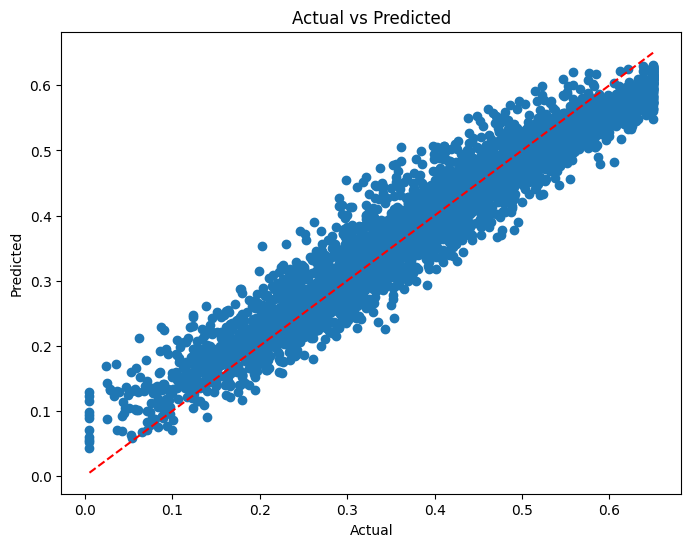

In [63]:
# Actual vs Predicted for Random Forest
plt.figure(figsize=(8,6))
plt.scatter(y_test,
            rfr_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## DecisionTree Regressor Model

In [64]:
dtr = DecisionTreeRegressor(
    max_depth=None
)
dtr.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

In [65]:
print(f"DecisionTreeRegressor Traning Score : {dtr.score(X_train,y_train)}")
print(f"DecisionTreeRegressor Testing Score : {dtr.score(X_test,y_test)}")

DecisionTreeRegressor Traning Score : 1.0
DecisionTreeRegressor Testing Score : 0.8485359008121601


In [66]:
dtr_pred = dtr.predict(X_test)

In [67]:
DecisionTreeRegressor_result = regression_model_performance(y_test, dtr_pred)

Model Performance
------------------------------
MSE  : 0.0029677730000000004
MAE  : 0.042405500000000006
RMSE : 0.054477270489627146
R² Score : 0.8485359008121601


In [68]:
# features importance
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dtr.feature_importances_
})
xgb_importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

,Feature,Importance
17,Water_Stress_Index,0.493630
13,Nitrogen,0.143184
8,Rainfall_mm,0.118785
15,Potassium,0.103364
14,Phosphorus,0.102766
11,Drought_Index,0.008812
10,Solar_Radiation_W_m2,0.004329
12,Soil_pH,0.004169
7,Temperature_C,0.003403
0,Tree_Name,0.003378


In [69]:
# cross validation
dtr_cv_scores = cross_val_score(
    dtr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("CV Scores:", dtr_cv_scores)
print("Mean CV Score:", np.mean(dtr_cv_scores))

CV Scores: [0.86145024 0.85830488 0.86124264 0.85116586 0.85243092]
Mean CV Score: 0.8569189085173459


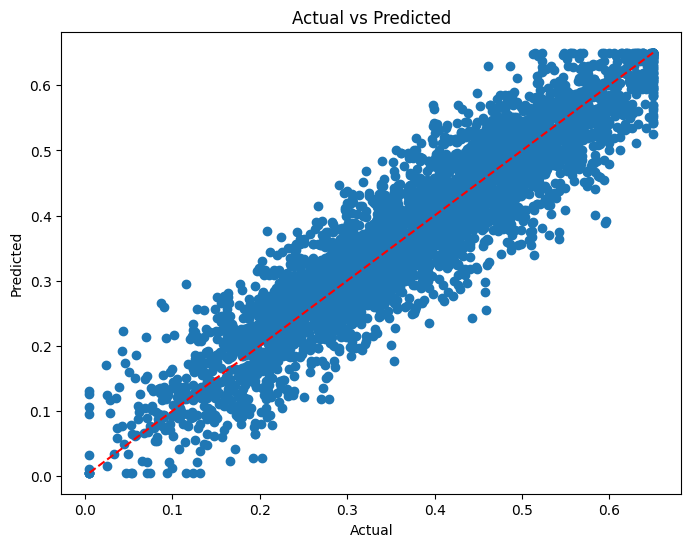

In [70]:
# Actual vs Predicted for Decision Tree
plt.figure(figsize=(8,6))
plt.scatter(y_test,
            dtr_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## XGBRegressor Model

In [71]:
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1

)
xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [72]:
print(f"XGBRegressor Traning Score : {xgb.score(X_train,y_train)}")
print(f"XGBRegressor Testing Score : {xgb.score(X_test,y_test)}")

XGBRegressor Traning Score : 0.9687839968975369
XGBRegressor Testing Score : 0.9457531053200954


In [73]:
xgb_pred = xgb.predict(X_test)

In [74]:
XGBRegressor_result = regression_model_performance(y_test, xgb_pred)

Model Performance
------------------------------
MSE  : 0.0010629084398752998
MAE  : 0.024531135750009214
RMSE : 0.03260227660571114
R² Score : 0.9457531053200954


In [80]:
# features importance
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})
xgb_importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

,Feature,Importance
17,Water_Stress_Index,0.374796
8,Rainfall_mm,0.183462
18,Fertilizer_Usage,0.123238
13,Nitrogen,0.100174
15,Potassium,0.076873
14,Phosphorus,0.072427
11,Drought_Index,0.044386
7,Temperature_C,0.002774
9,Humidity_Pct,0.002438
4,Canopy_Width_m,0.002301


In [81]:

df_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": xgb_pred
})

# =========================
# ERROR CALCULATION
# =========================

# Residual (signed error)
df_results["Error"] = df_results["Actual"] - df_results["Predicted"]

# Absolute Error
df_results["Abs_Error"] = np.abs(df_results["Error"])


print(df_results.head())


       Actual  Predicted     Error  Abs_Error
10650   0.486   0.472182  0.013818   0.013818
2041    0.235   0.224772  0.010228   0.010228
8668    0.419   0.425721 -0.006721   0.006721
1114    0.481   0.466928  0.014072   0.014072
13902   0.230   0.248738 -0.018738   0.018738


In [77]:
# cross validation
xgb_cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("CV Scores:", xgb_cv_scores)
print("Mean CV Score:", np.mean(xgb_cv_scores))

CV Scores: [0.94825149 0.94377405 0.94575769 0.94632395 0.94379252]
Mean CV Score: 0.9455799395995484


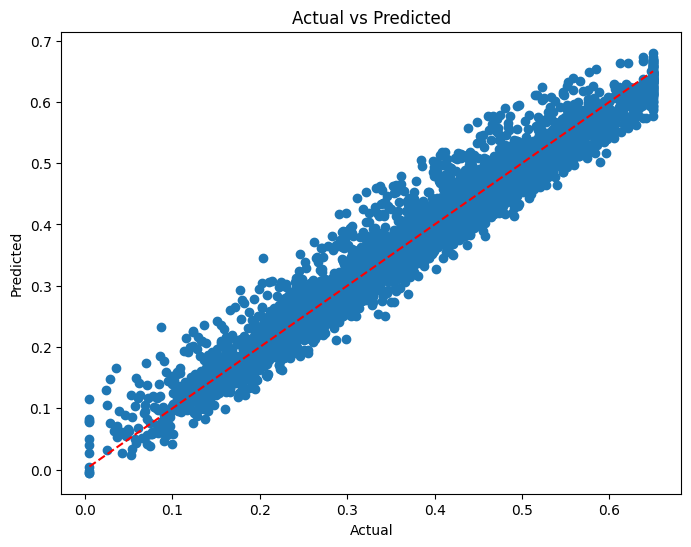

In [78]:
# Actual vs Predicted for XGBoost

plt.figure(figsize=(8,6))
plt.scatter(y_test,
            xgb_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## CatBoostRegressor Model

In [83]:
cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    l2_leaf_reg=5,
    subsample=0.8,
    verbose=0
)
cat.fit(X_train,y_train)

CatBoostRegressor(depth=6, eval_metric='R2', iterations=1000, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, subsample=0.8, verbose=0)

In [84]:
print(f"Traing Score : {cat.score(X_train,y_train)}")
print(f"Testing Score : {cat.score(X_test,y_test)}")

Traing Score : 0.9570237154574657
Testing Score : 0.948542838897123


In [85]:
cat_pred = cat.predict(X_test)

In [86]:
catboost_result = regression_model_performance(y_test,cat_pred)

Model Performance
------------------------------
MSE  : 0.0010082466683301618
MAE  : 0.023756322066440738
RMSE : 0.031752900156208755
R² Score : 0.948542838897123


In [87]:

df_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": cat_pred
})

# =========================
# ERROR CALCULATION
# =========================

# Residual (signed error)
df_results["Error"] = df_results["Actual"] - df_results["Predicted"]

# Absolute Error
df_results["Abs_Error"] = np.abs(df_results["Error"])


print(df_results.head())


       Actual  Predicted     Error  Abs_Error
10650   0.486   0.478358  0.007642   0.007642
2041    0.235   0.234352  0.000648   0.000648
8668    0.419   0.426531 -0.007531   0.007531
1114    0.481   0.469867  0.011133   0.011133
13902   0.230   0.247965 -0.017965   0.017965


In [88]:
# features importance
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": cat.feature_importances_
})
xgb_importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

,Feature,Importance
13,Nitrogen,22.649139
8,Rainfall_mm,17.972328
15,Potassium,16.618027
14,Phosphorus,16.361756
17,Water_Stress_Index,13.376317
18,Fertilizer_Usage,5.952485
11,Drought_Index,5.705019
16,Organic_Carbon,0.208944
10,Solar_Radiation_W_m2,0.205557
9,Humidity_Pct,0.183135


In [35]:
# cross validation

cat_cv_scores = cross_val_score(
    cat,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("CV Scores:", cat_cv_scores)
print("Mean CV Score:", np.mean(cat_cv_scores))

CV Scores: [0.95102919 0.94563204 0.94835339 0.94871044 0.94585441]
Mean CV Score: 0.9479158949163606


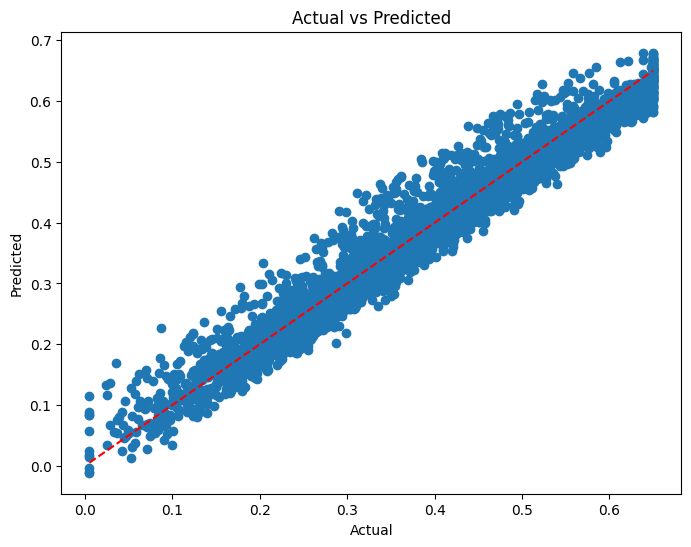

In [36]:
# Acutal V/S Predication 

plt.figure(figsize=(8,6))
plt.scatter(y_test,
            cat_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## Hyperparamter Tuning

In [ ]:
# XGBoost model
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.07],
    'n_estimators': [200, 300, 400]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(f"Best parameters for model : {grid.best_params_}")
print(f"Best Score for model : {grid.best_score_}")

In [109]:
# RandomForestRegressor model 

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500, 700],
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rfr_random = RandomizedSearchCV(
    estimator=rfr,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

rfr_random.fit(X_train, y_train)

print(f"Best Parameters : { rfr_random.best_params_}")
print(f"Best CV Score: {rfr_random.best_score_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters : {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 25, 'bootstrap': True}
Best CV Score: 0.8340613209524985


## Model Performance comparison

In [37]:
results = []


results.append([
    "Random Forest",
    rfr.score(X_train,y_train),
    rfr.score(X_test,y_test),
    RandomForestRegressor_result["R2 Score"],
    RandomForestRegressor_result["MAE"],
    RandomForestRegressor_result["RMSE"]
])

results.append([
    "Decision Tree",
    dtr.score(X_train,y_train),
    dtr.score(X_test,y_test),
    DecisionTreeRegressor_result["R2 Score"],
    DecisionTreeRegressor_result["MAE"],
    DecisionTreeRegressor_result["RMSE"]
])

results.append([
    "XGBoost",
    xgb.score(X_train,y_train),
    xgb.score(X_test,y_test),
    XGBRegressor_result["R2 Score"],
    XGBRegressor_result["MAE"],
    XGBRegressor_result["RMSE"]
])

results.append([
    "CatBoost",
    cat.score(X_train,y_train),
    cat.score(X_test,y_test),
    catboost_result["R2 Score"],
    catboost_result["MAE"],
    catboost_result["RMSE"]
])


comparison = pd.DataFrame(
    results,
    columns=["Model","Training Score","Testing Score" ,"R2 Score", "MAE", "RMSE"]
)


## Cross Validation Mean Comparison

In [38]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Decision Tree",
        "XGBoost",
        "CatBoost"
    ],
    "CV Mean R2": [
        np.mean(rfr_cv_scores),
        np.mean(dtr_cv_scores),
        np.mean(xgb_cv_scores),
        np.mean(cat_cv_scores)
    ],
    "CV Std": [
        np.std(rfr_cv_scores),
        np.std(dtr_cv_scores),
        np.std(xgb_cv_scores),
        np.std(cat_cv_scores)
    ]
})

cv_comparison.sort_values(
    by="CV Mean R2",
    ascending=False,
    inplace=True
)
cv_comparison.reset_index(drop=True, inplace=True)


## Final Model Comparison Table

In [40]:
final_comparison = comparison.merge(
    cv_comparison,
    on="Model"
)

final_comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,Training Score,Testing Score,R2 Score,MAE,RMSE,CV Mean R2,CV Std
3,CatBoost,0.956684,0.948763,0.948763,0.023670,0.031685,0.947916,0.001999
2,XGBoost,0.968499,0.945896,0.945896,0.024457,0.032559,0.945403,0.002044
0,Random Forest,0.958812,0.920204,0.920204,0.031012,0.039541,0.918549,0.003083
1,Decision Tree,1.000000,0.849094,0.849094,0.042371,0.054377,0.858965,0.003947


## Best Model Selection

In [41]:
best_model = comparison.sort_values(
    by="Testing Score",
    ascending=False
)

best_model.head(1)

,Model,Training Score,Testing Score,R2 Score,MAE,RMSE
3,CatBoost,0.956684,0.948763,0.948763,0.02367,0.031685


## Save Model

In [ ]:
import joblib

joblib.dump(
    xgb,
    "../models/Growth_Prediction_Model.pkl"
)
joblib.dump(X.columns.tolist(),
            "../models/Growth_feature_columns.pkl")

['../models/Growth_feature_columns_2.pkl']